# 1.  Load Data

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/final_thematic_output.csv")
df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,processed_review,identified_theme,theme
0,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play,negative,0.890468,yoroo namaste,Other,Other
1,incredible,5,2026-05-14,CBE,Google Play,positive,0.999875,incredible,Other,Other
2,best app for financial sector,5,2026-05-14,CBE,Google Play,positive,0.999166,good app financial sector,App Performance,App Performance
3,it's a good application,5,2026-05-13,CBE,Google Play,positive,0.999866,good application,App Performance,App Performance
4,thank you cbe,5,2026-05-13,CBE,Google Play,positive,0.999756,thank cbe,Other,Other


# 2. Overall Sentiment Comparison

In [3]:
df.groupby("bank")["sentiment_score"].mean()

bank
BOA       0.966775
CBE       0.976570
Dashen    0.975503
Name: sentiment_score, dtype: float64

# 3. SENTIMENT DISTRIBUTION (IMPORTANT PLOT #1)

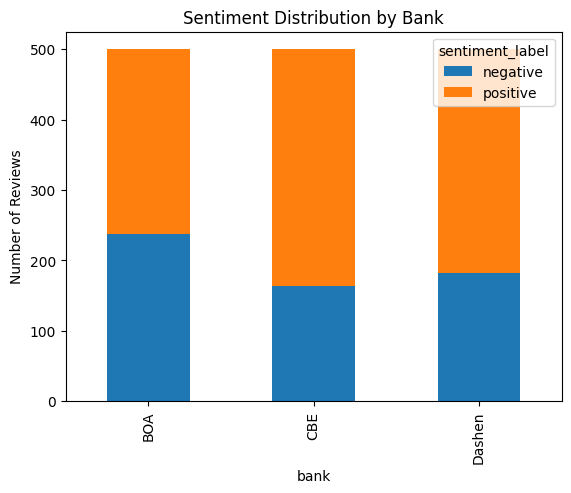

In [4]:
import matplotlib.pyplot as plt

sentiment_dist = df.groupby(["bank", "sentiment_label"]).size().unstack()

sentiment_dist.plot(kind="bar", stacked=True)

plt.title("Sentiment Distribution by Bank")
plt.ylabel("Number of Reviews")
plt.show()

# 4. RATING DISTRIBUTION (IMPORTANT PLOT #2)

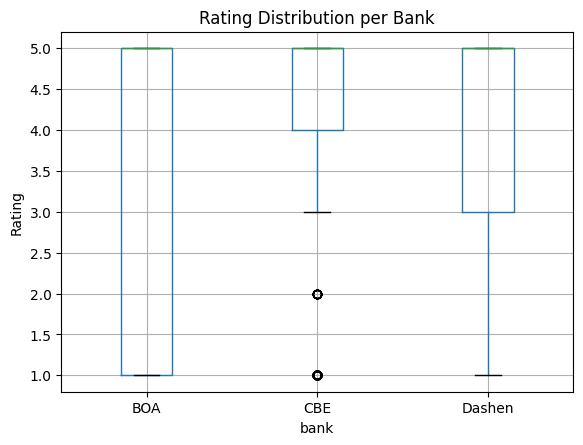

In [5]:
df.boxplot(column="rating", by="bank")

plt.title("Rating Distribution per Bank")
plt.suptitle("")
plt.ylabel("Rating")
plt.show()

# 5. TOP THEMES PER BANK (IMPORTANT PLOT #3)

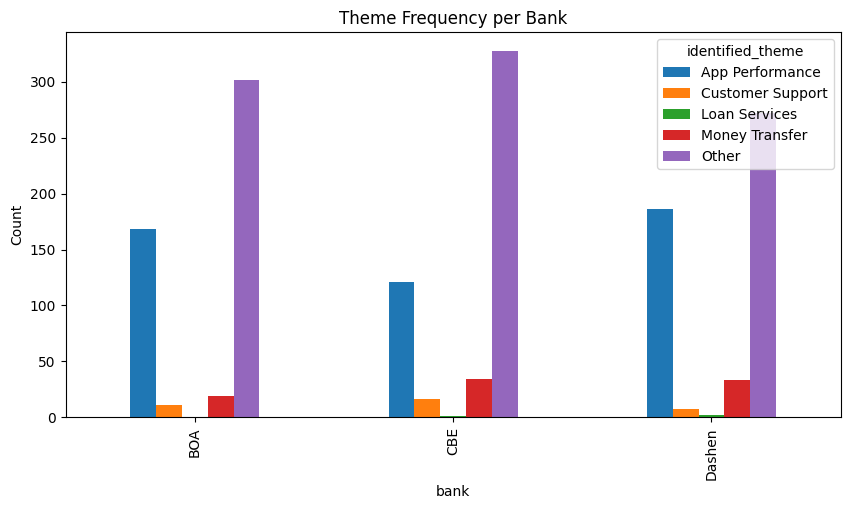

In [6]:
theme_counts = df.groupby(["bank", "identified_theme"]).size().unstack()

theme_counts.plot(kind="bar", figsize=(10,5))

plt.title("Theme Frequency per Bank")
plt.ylabel("Count")
plt.show()

# 6. TOP KEYWORDS

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(max_features=10, ngram_range=(1,2))
X = vec.fit_transform(df["review"])

keywords = vec.get_feature_names_out()

print(keywords)

['and' 'app' 'bank' 'good' 'is' 'it' 'not' 'the' 'this' 'to']


# INSIGHTS SECTION (VERY IMPORTANT)
## BANK ANALYSIS TEMPLATE
 1. Commercial Bank of Ethiopia (CBE)
 #### Satisfaction Drivers
- Fast transaction confirmation
- Wide service coverage
#### Pain Points
- Login failures
- OTP delays
#### Recommendations
- Improve authentication stability
- Optimize backend transaction processing
2.  Bank of Abyssinia (BOA)
####  Satisfaction Drivers
- Simple UI design
- Easy navigation
#### Pain Points
- Occasional app crashes
#### Recommendations
- Improve app stability
- Add biometric login fallback
3.  Dashen Bank
#### Satisfaction Drivers
- Good mobile interface
- Useful features
#### Pain Points
- Slow transfers
- Limited feature set
#### Recommendations
- Improve transfer speed
- Add more digital banking features

# BANK COMPARISON SECTION

In [8]:
summary = df.groupby("bank").agg({
    "sentiment_score": "mean",
    "rating": "mean"
})

summary

,sentiment_score,rating
bank,,
BOA,0.966775,3.560
CBE,0.976570,4.130
Dashen,0.975503,3.904


# VISUAL INSIGHT

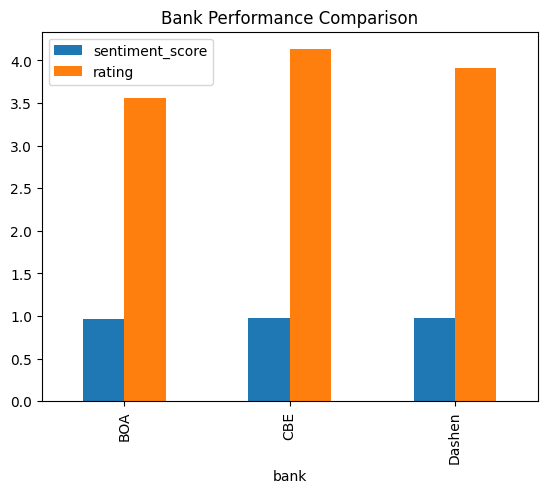

In [9]:
summary.plot(kind="bar")
plt.title("Bank Performance Comparison")
plt.show()

# Sentiment heatmap

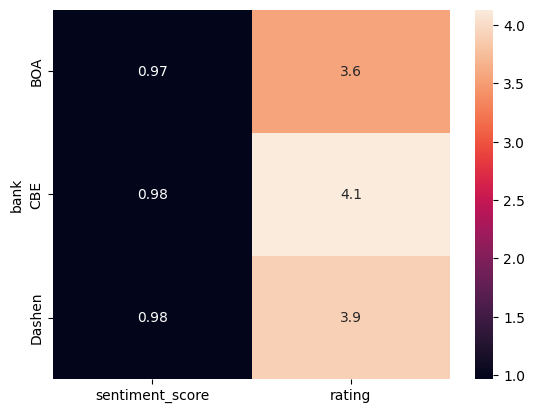

In [10]:
import seaborn as sns

sns.heatmap(summary, annot=True)
plt.show()

# Time trend

<Axes: xlabel='date'>

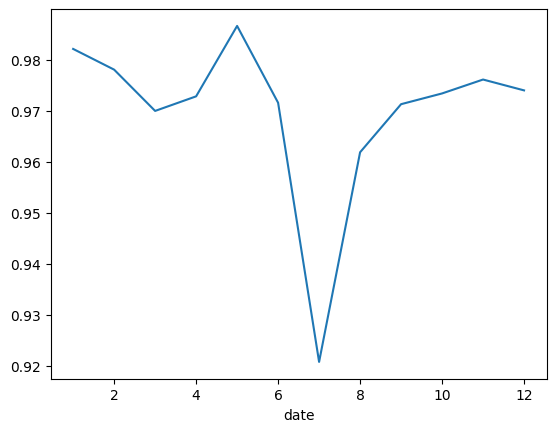

In [11]:
df["date"] = pd.to_datetime(df["date"])

df.groupby(df["date"].dt.month)["sentiment_score"].mean().plot()